# Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [63]:
print(sys.version)

3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


# Task 1 (a) - Data Exploration

In [65]:
high_HNR_train = pd.read_excel('parkinsons_HighHNR_training-2_12624337.xlsx')
high_HNR_test = pd.read_excel('parkinsons_HighHNR_test-1_12624345.xlsx')
low_HNR_train = pd.read_excel('parkinsons_LowHNR_training-1_12624346.xlsx')
low_HNR_test = pd.read_excel('parkinsons_LowHNR_test-1_12624351.xlsx')

In [66]:
high_HNR_train.head()

,subject_id,status,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S02,1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,...,0.01351,0.02337,0.00607,24.886,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
1,phon_R01_S02,1,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,...,0.01256,0.02487,0.00344,26.892,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
2,phon_R01_S02,1,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,...,0.01717,0.03218,0.01070,21.812,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
3,phon_R01_S02,1,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,...,0.02444,0.04324,0.01022,21.862,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362
4,phon_R01_S02,1,88.333,112.240,84.072,0.00505,0.00006,0.00254,0.00330,0.00763,...,0.01892,0.03237,0.01166,21.118,0.611137,0.776156,-5.249770,0.391002,2.407313,0.249740


In [67]:
x1 = high_HNR_train.iloc[:,2:]
y1 = high_HNR_train.iloc[:,1]

x2 = low_HNR_train.iloc[:,2:]
y2 = low_HNR_train.iloc[:,1]

x3 = high_HNR_test.iloc[:,2:]
y3 = high_HNR_test.iloc[:,1]

x4 = low_HNR_test.iloc[:,2:]
y4 = low_HNR_test.iloc[:,1]

In [68]:
print(x1.shape)
print(y1.shape)

(66, 22)
(66,)


# Task 1 (b)

In [70]:
x1.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.140,...,0.01351,0.02337,0.00607,24.886,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
1,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,...,0.01256,0.02487,0.00344,26.892,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
2,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.191,...,0.01717,0.03218,0.01070,21.812,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
3,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,0.255,...,0.02444,0.04324,0.01022,21.862,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362
4,88.333,112.240,84.072,0.00505,0.00006,0.00254,0.00330,0.00763,0.02143,0.197,...,0.01892,0.03237,0.01166,21.118,0.611137,0.776156,-5.249770,0.391002,2.407313,0.249740


In [71]:
first_feature = 1
second_feature = 2

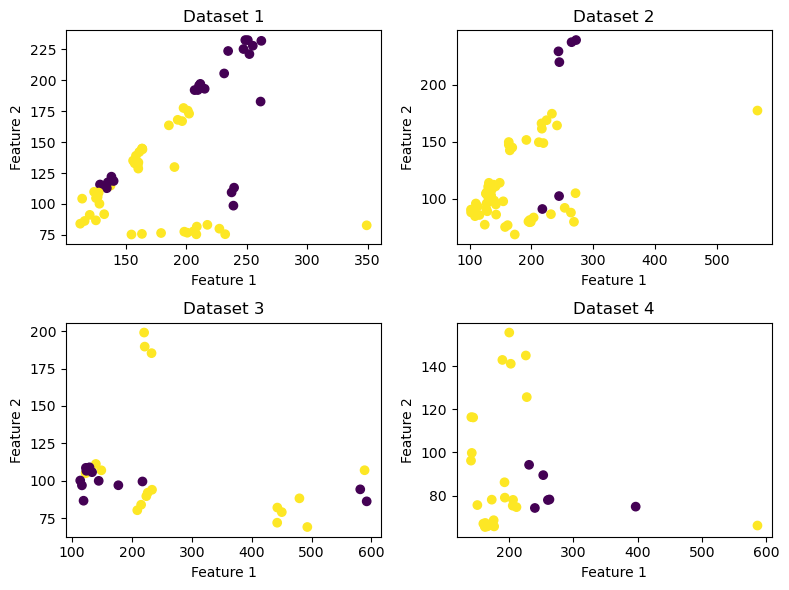

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))
datasets = [(x1,y1), (x2,y2), (x3,y3), (x4,y4)]
titles = ["Dataset 1","Dataset 2","Dataset 3","Dataset 4"]

for i, ax in enumerate(axes.flatten()):

    X, y = datasets[i]
    ax.scatter(X.iloc[:,first_feature], X.iloc[:,second_feature],
               c=y,
               cmap='viridis')

    ax.set_title(titles[i])
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.savefig('my_figure.png', dpi=300, bbox_inches='tight')
plt.show()

# Task 1 (c)

In [74]:
# Normalization of data using StandardScaler()

In [75]:
sc = StandardScaler()

high_HNR_train_scaled = sc.fit_transform(x1)
high_HNR_test_scaled = sc.transform(x3)

low_HNR_train_scaled = sc.fit_transform(x2)
low_HNR_test_scaled = sc.transform(x4)

In [76]:
### Calculating mean & standard deviation for test sets

In [77]:
high_HNR_test_scaled[:,0]

array([-0.99062037, -1.17624989, -1.20434977, -1.20632896, -1.15641198,
       -1.20952789,  0.68823823,  0.86507647,  1.04469938,  0.95598108,
        1.0820278 ,  0.99425307, -0.25896482, -0.11289607,  0.17562827,
        0.34889936,  1.24254924, -0.78671788,  0.31527616, -1.16398352,
       -1.20559252, -1.13710338, -1.0614109 , -1.09878536, -1.07558742,
       -1.05630183, -1.06500106, -1.07793483, -1.0717211 , -1.07664605,
       -1.11758765])

In [78]:
high_test_mean = high_HNR_test_scaled[:,0].mean()
low_test_mean = low_HNR_test_scaled[:,0].mean()

high_test_std = high_HNR_test_scaled[:,0].std()
low_test_std = low_HNR_test_scaled[:,0].std()

In [79]:
print("Mean of high HNR: ", high_test_mean)
print("Standard Deviation of high HNR: ", high_test_std)

print()

print("Mean of low HNR: ", low_test_mean)
print("Standard Deviation of low HNR: ", low_test_std)

Mean of high HNR:  -0.43861594149872646
Standard Deviation of high HNR:  0.8898900935581869

Mean of low HNR:  0.31067677053217074
Standard Deviation of low HNR:  0.5753608581399678


# Task 1 (d)

In [81]:
pca1 = PCA()
first_pca = pca1.fit_transform(high_HNR_train_scaled)

In [82]:
variance1 = pca1.explained_variance_ratio_
variance_percentage1 = variance1 * 100

In [83]:
variance_percentage1

array([5.79641947e+01, 1.42079061e+01, 7.91736514e+00, 5.58316728e+00,
       3.62999223e+00, 3.15911429e+00, 2.24625428e+00, 1.55791552e+00,
       9.87685242e-01, 8.42856953e-01, 5.86636823e-01, 4.23096607e-01,
       3.57051350e-01, 1.99644453e-01, 1.53220608e-01, 7.60541300e-02,
       4.91111024e-02, 3.65365911e-02, 1.93011201e-02, 2.86836570e-03,
       2.56420084e-05, 1.48181676e-06])

In [84]:
variance_table1 = pd.DataFrame({
    "Principal Component": ["PC1","PC2","PC3","PC4","PC5","PC6","PC7"],
    "Variance Explained (%)": variance_percentage1[:7]
})

print(variance_table1)

  Principal Component  Variance Explained (%)
0                 PC1               57.964195
1                 PC2               14.207906
2                 PC3                7.917365
3                 PC4                5.583167
4                 PC5                3.629992
5                 PC6                3.159114
6                 PC7                2.246254


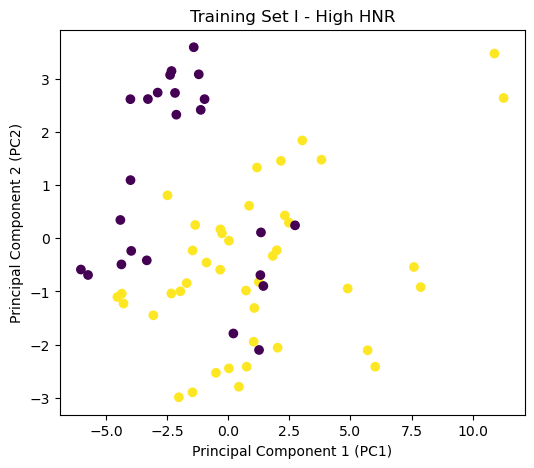

In [85]:
plt.figure(figsize=(6,5))

plt.scatter(
    first_pca[:,0],
    first_pca[:,1],
    c=y1,
    cmap="viridis"
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Training Set I - High HNR")

plt.savefig('my_figure2.png', dpi=300, bbox_inches='tight')

plt.show()

In [86]:
# Second PCA
pca2 = PCA()
second_pca = pca2.fit_transform(low_HNR_train_scaled)

In [87]:
variance2 = pca2.explained_variance_ratio_
variance_percentage2 = variance2 * 100
variance_percentage2

array([5.78117512e+01, 1.49283130e+01, 7.81579316e+00, 6.84331186e+00,
       3.47976213e+00, 2.57909944e+00, 2.03991713e+00, 1.46648656e+00,
       9.38267570e-01, 7.01815111e-01, 5.00030832e-01, 3.39114908e-01,
       2.00394275e-01, 1.23070407e-01, 9.27862441e-02, 6.77471877e-02,
       4.48948388e-02, 1.33837126e-02, 8.65848573e-03, 5.40050414e-03,
       1.25156514e-06, 1.54727005e-07])

In [88]:
variance_table2 = pd.DataFrame({
    "Principal Component": ["PC1","PC2","PC3","PC4","PC5","PC6","PC7"],
    "Variance Explained (%)": variance_percentage2[:7]
})

print(variance_table2)

  Principal Component  Variance Explained (%)
0                 PC1               57.811751
1                 PC2               14.928313
2                 PC3                7.815793
3                 PC4                6.843312
4                 PC5                3.479762
5                 PC6                2.579099
6                 PC7                2.039917


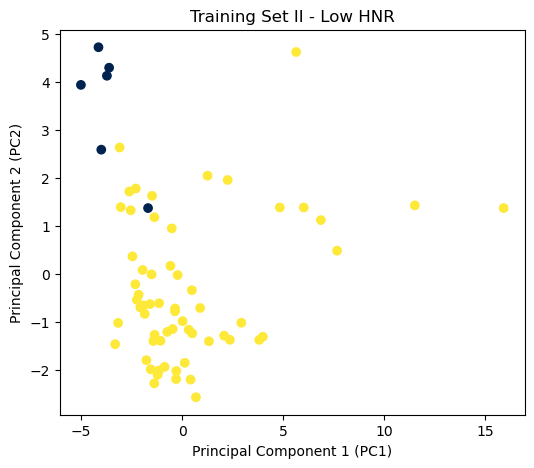

In [89]:
plt.figure(figsize=(6,5))

plt.scatter(
    second_pca[:,0],
    second_pca[:,1],
    c=y2,
    cmap="cividis"
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("Training Set II - Low HNR")

plt.savefig('my_figure3.png', dpi=300, bbox_inches='tight')
plt.show()

In [90]:
pca_table = pd.DataFrame({
    "Principal Component": ["PC1","PC2","PC3","PC4","PC5","PC6","PC7"],
    "   High-HNR Variance (%)": variance_percentage1[:7],
    "   Low-HNR Variance (%)": variance_percentage2[:7]
})

print(pca_table)

  Principal Component     High-HNR Variance (%)     Low-HNR Variance (%)
0                 PC1                 57.964195                57.811751
1                 PC2                 14.207906                14.928313
2                 PC3                  7.917365                 7.815793
3                 PC4                  5.583167                 6.843312
4                 PC5                  3.629992                 3.479762
5                 PC6                  3.159114                 2.579099
6                 PC7                  2.246254                 2.039917


# Task 2: SVM Classification on HighHNR Group

In [92]:
x1.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,0.140,...,0.01351,0.02337,0.00607,24.886,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
1,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,0.134,...,0.01256,0.02487,0.00344,26.892,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
2,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,0.191,...,0.01717,0.03218,0.01070,21.812,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
3,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,0.255,...,0.02444,0.04324,0.01022,21.862,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362
4,88.333,112.240,84.072,0.00505,0.00006,0.00254,0.00330,0.00763,0.02143,0.197,...,0.01892,0.03237,0.01166,21.118,0.611137,0.776156,-5.249770,0.391002,2.407313,0.249740


In [93]:
y1.head()

0    1
1    1
2    1
3    1
4    1
Name: status, dtype: int64

In [94]:
X_train, X_val, y_train, y_val = train_test_split(x1, y1, test_size=0.2, random_state=42)

In [95]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(52, 22)
(52,)
(14, 22)
(14,)


In [96]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(pd.DataFrame(X_val))

y_train_scaled = scaler.fit_transform(pd.DataFrame(y_train))
y_val_scaled = scaler.transform(pd.DataFrame(y_val))

In [97]:
train_mean = np.mean(X_train_scaled, axis=0)
train_std = np.std(X_train_scaled, axis=0)

val_mean = np.mean(X_val_scaled, axis=0)
val_std = np.std(X_val_scaled, axis=0)

In [98]:
df_compare = pd.DataFrame({
    "Feature": [f"F{i+1}" for i in range(len(train_mean))],
    "Train Mean": train_mean,
    "Val Mean": val_mean,
    "Train Std": train_std,
    "Val Std": val_std
})

print(df_compare)

   Feature    Train Mean  Val Mean  Train Std   Val Std
0       F1  7.632783e-16 -0.214186        1.0  1.089347
1       F2 -3.362695e-16  0.010471        1.0  0.924351
2       F3 -1.574595e-16 -0.102180        1.0  1.142521
3       F4  7.259151e-16  0.646020        1.0  1.117932
4       F5 -2.070993e-16  0.631506        1.0  1.211195
5       F6 -2.690156e-16  0.784628        1.0  1.193518
6       F7 -1.281027e-17  0.738518        1.0  1.170141
7       F8  4.910602e-16  0.783383        1.0  1.194190
8       F9  5.978124e-17  0.778782        1.0  1.455054
9      F10 -6.832142e-17  0.777765        1.0  1.495593
10     F11 -6.405133e-17  0.777738        1.0  1.342601
11     F12  3.202566e-16  0.767181        1.0  1.490060
12     F13  3.843080e-17  0.662751        1.0  1.513756
13     F14  3.416071e-16  0.777828        1.0  1.342636
14     F15  1.494531e-17  0.661769        1.0  1.360028
15     F16 -2.604754e-16 -0.598657        1.0  0.575821
16     F17 -4.697097e-17  0.004025        1.0  1

In [99]:
X_train_scaled[:,1].mean()

-3.362694738047349e-16

In [100]:
X_val_scaled[:,1].mean()

0.010471097336244656

# Task 2 (b)

In [102]:
model = SVC(C=1, gamma=1, kernel='rbf')

In [103]:
model.fit(X_train_scaled, y_train)

SVC(C=1, gamma=1)

In [104]:
y_pred = model.predict(X_val_scaled)

In [105]:
acc = accuracy_score(y_val, y_pred)

In [106]:
print(acc)

0.7857142857142857


In [107]:
model2 = SVC(C=20, gamma=0.5, kernel='rbf')
model2.fit(X_train_scaled, y_train)
y_pred = model2.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)
print(acc)

0.7857142857142857


In [108]:
model3 = SVC(C=0.5, gamma=0.1, kernel='rbf')
model3.fit(X_train_scaled, y_train)
y_pred = model3.predict(X_val_scaled)
acc = accuracy_score(y_val, y_pred)
print(acc)

1.0


In [109]:
print(confusion_matrix(y_val, y_pred))

[[ 4  0]
 [ 0 10]]


In [110]:
params = [(1,1), (20,0.5), (0.5,0.1)]

results = []

for C, gamma in params:
    
    model = SVC(kernel='rbf', C=C, gamma=gamma)
  
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_val_scaled)
    
    acc = accuracy_score(y_val, y_pred)
    
    results.append((C, gamma, acc))

In [111]:
for C, gamma, acc in results:
    print(f"C={C}, gamma={gamma}, Accuracy={acc:.4f}")

C=1, gamma=1, Accuracy=0.7857
C=20, gamma=0.5, Accuracy=0.7857
C=0.5, gamma=0.1, Accuracy=1.0000


# Task 2 (d)

In [113]:
scaler = StandardScaler()

whole_train_scaled = scaler.fit_transform(x1)
whole_test_scaled = scaler.transform(x3)

In [114]:
final_model_high = SVC(C=0.5, gamma=0.1, kernel='rbf')
final_model_high.fit(whole_train_scaled, y1)
y_pred = final_model_high.predict(whole_test_scaled)
acc = accuracy_score(y3, y_pred)
print(acc)

0.6129032258064516


In [115]:
print(confusion_matrix(y3, y_pred))

[[ 0 12]
 [ 0 19]]


# Task 3: SVM Classification on LowHNR Group

In [117]:
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(x2, y2, test_size=0.2, random_state=42)

In [118]:
print(X_train_low.shape)
print(y_train_low.shape)
print(X_val_low.shape)
print(y_val_low.shape)

(53, 22)
(53,)
(14, 22)
(14,)


In [119]:
scaler = StandardScaler()

X_train_low_scaled = scaler.fit_transform(X_train_low)
X_val_low_scaled = scaler.transform(pd.DataFrame(X_val_low))

y_train_low_scaled = scaler.fit_transform(pd.DataFrame(y_train_low))
y_val_low_scaled = scaler.transform(pd.DataFrame(y_val_low))

In [120]:
train_mean = np.mean(X_train_low_scaled, axis=0)
train_std = np.std(X_train_low_scaled, axis=0)

val_mean = np.mean(X_val_low_scaled, axis=0)
val_std = np.std(X_val_low_scaled, axis=0)

In [121]:
df_compare = pd.DataFrame({
    "Feature": [f"F{i+1}" for i in range(len(train_mean))],
    "Train Mean": train_mean,
    "Val Mean": val_mean,
    "Train Std": train_std,
    "Val Std": val_std
})

print(df_compare)

   Feature    Train Mean  Val Mean  Train Std   Val Std
0       F1  7.122185e-17  0.107174        1.0  1.018624
1       F2  4.817949e-17  0.670624        1.0  2.294629
2       F3  1.026433e-16 -0.308179        1.0  0.704562
3       F4 -1.927180e-16 -0.109172        1.0  0.632822
4       F5 -1.403489e-16 -0.129734        1.0  0.785335
5       F6  1.906232e-16 -0.159489        1.0  0.612962
6       F7 -8.379042e-17 -0.026340        1.0  0.710372
7       F8 -2.199498e-17 -0.159429        1.0  0.612592
8       F9 -3.728674e-16 -0.334779        1.0  0.783081
9      F10  8.379042e-18 -0.348197        1.0  0.812144
10     F11 -9.007470e-17 -0.345150        1.0  0.774723
11     F12 -1.026433e-16 -0.221767        1.0  0.829077
12     F13  2.251867e-16 -0.348226        1.0  0.603297
13     F14  9.007470e-17 -0.345122        1.0  0.774754
14     F15 -1.167829e-16 -0.359621        1.0  0.449506
15     F16  4.608473e-17  0.339150        1.0  0.661542
16     F17 -5.090268e-16 -0.547471        1.0  1

# Task 3 (b)

In [123]:
model = SVC(C=1, gamma=1, kernel='rbf')

In [124]:
model.fit(X_train_low_scaled, y_train_low)

SVC(C=1, gamma=1)

In [125]:
y_pred = model.predict(X_val_low_scaled)

In [126]:
acc = accuracy_score(y_val_low, y_pred)
print(acc)

0.8571428571428571


In [127]:
model2 = SVC(C=20, gamma=0.5, kernel='rbf')
model2.fit(X_train_low_scaled, y_train_low)
y_pred = model2.predict(X_val_low_scaled)
acc = accuracy_score(y_val_low, y_pred)
print(acc)

0.8571428571428571


In [128]:
model3 = SVC(C=0.5, gamma=0.1, kernel='rbf')
model3.fit(X_train_low_scaled, y_train_low)
y_pred = model3.predict(X_val_low_scaled)
acc = accuracy_score(y_val_low, y_pred)
print(acc)

0.8571428571428571


In [129]:
print(confusion_matrix(y_val_low, y_pred))

[[ 0  2]
 [ 0 12]]


In [130]:
params = [(1,1), (20,0.5), (0.5,0.1)]

results = []

for C, gamma in params:
    
    model = SVC(kernel='rbf', C=C, gamma=gamma)
  
    model.fit(X_train_low_scaled, y_train_low)
    
    y_pred = model.predict(X_val_low_scaled)
    
    acc = accuracy_score(y_val_low, y_pred)
    
    results.append((C, gamma, acc))

In [131]:
for C, gamma, acc in results:
    print(f"C={C}, gamma={gamma}, Accuracy={acc:.4f}")

C=1, gamma=1, Accuracy=0.8571
C=20, gamma=0.5, Accuracy=0.8571
C=0.5, gamma=0.1, Accuracy=0.8571


# Task 3 (d)

In [133]:
scaler = StandardScaler()

whole_train_low_scaled = scaler.fit_transform(x2)
whole_test_low_scaled = scaler.transform(x4)

In [134]:
final_model_low = SVC(C=0.5, gamma=0.1, kernel='rbf')
final_model_low.fit(whole_train_low_scaled, y2)
y_pred = final_model_low.predict(whole_test_low_scaled)
acc = accuracy_score(y4, y_pred)
print(acc)

0.8064516129032258


In [135]:
print(confusion_matrix(y4, y_pred))

[[ 0  6]
 [ 0 25]]


# Task 4: Cross Model Check

# Task 4 (a)

In [138]:
high_predictions = final_model_high.predict(whole_test_low_scaled)
acc_high = accuracy_score(y4, high_predictions)
print(acc_high)

0.9032258064516129


In [139]:
print(confusion_matrix(y4, high_predictions))

[[ 3  3]
 [ 0 25]]


# Task 4 (b)

In [141]:
low_predictions = final_model_low.predict(whole_test_scaled)
acc_low = accuracy_score(y3, low_predictions)
print(acc_low)

0.6129032258064516


In [210]:
print(confusion_matrix(y3, low_predictions))

[[ 0 12]
 [ 0 19]]
